In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import math

class PatientEnvGymShapedReward(gym.Env):
    def __init__(self):
        super().__init__()
        print("Shaped Reward Stochastic Environment created!")

        # --- Parameters are the same ---
        self.base_decay_rate = 0.1
        self.decay_noise_level = 0.02
        self.target_min = 5.0
        self.target_max = 15.0
        self.action_space = spaces.Box(low=0.0, high=20.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=0.0, high=100.0, shape=(1,), dtype=np.float32)
        self.max_steps = 100

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_concentration = 0.0
        self.current_step = 0
        return np.array([self.current_concentration]).astype(np.float32), {}

    def step(self, action):
        dosage_administered = np.asarray(action).item()
        
        # --- Physics are the same ---
        random_noise = np.random.normal(loc=0.0, scale=self.decay_noise_level)
        current_decay_rate = self.base_decay_rate + random_noise
        current_decay_rate = max(0.01, current_decay_rate)
        drug_cleared = self.current_concentration * current_decay_rate
        self.current_concentration += dosage_administered - drug_cleared
        self.current_concentration = max(0, self.current_concentration)
        
        # === THE CORE CHANGE: SHAPED REWARD ===
        target_center = (self.target_max + self.target_min) / 2.0
        distance_from_center = abs(self.current_concentration - target_center)
        
        # We use a negative exponential. Reward is highest (near 0) at the center
        # and becomes more negative the farther away we are.
        # This provides a smooth gradient for the agent to learn from.
        reward = -math.exp(distance_from_center / target_center)

        self.current_step += 1
        terminated = False 
        truncated = self.current_step >= self.max_steps
        next_state = np.array([self.current_concentration]).astype(np.float32)
        
        return next_state, reward, terminated, truncated, {}

In [2]:
from stable_baselines3 import PPO

env = PatientEnvGymShapedReward()

model = PPO('MlpPolicy', env, verbose=1)

model.learn(total_timesteps=150000)

print("Training finished!")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Shaped Reward Stochastic Environment created!
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | -195     |
| time/              |          |
|    fps             | 1662     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 100         |
|    ep_rew_mean          | -188        |
| time/                   |             |
|    fps                  | 1256        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008631438 |
|    clip_fraction        | 0.106       |
|    clip_range 

In [3]:
import gymnasium as gym
import numpy as np
import pickle
from stable_baselines3 import PPO

# === 1. Load the trained PPO model ===
env = PatientEnvGymShapedReward()

# === 2. Prepare storage ===
dataset = {
    "observations": [],
    "actions": [],
    "rewards": [],
    "next_observations": [],
    "dones": []
}

# === 3. Collect rollouts ===
num_samples = 25000
obs, _ = env.reset()
for _ in range(num_samples):
    # Get action from PPO policy
    action, _ = model.predict(obs, deterministic=True)
    
    # Step environment
    next_obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    
    # Store transition
    dataset["observations"].append(obs)
    dataset["actions"].append(action)
    dataset["rewards"].append(reward)
    dataset["next_observations"].append(next_obs)
    dataset["dones"].append(done)
    
    obs = next_obs
    
    # Reset if done
    if done:
        obs, _ = env.reset()

# === 4. Convert lists to numpy arrays for consistency ===
for key in dataset:
    dataset[key] = np.array(dataset[key])

# === 5. Save as .pkl ===
with open("ppo_collected_dataset_shaped.pkl", "wb") as f:
    pickle.dump(dataset, f)

print("✅ Dataset saved as 'ppo_collected_dataset_shaped.pkl' with", len(dataset["observations"]), "samples.")


Shaped Reward Stochastic Environment created!
✅ Dataset saved as 'ppo_collected_dataset.pkl' with 25000 samples.


In [4]:
import pickle
import numpy as np
from d3rlpy.dataset import MDPDataset

# === 1. Load dataset ===
with open('ppo_collected_dataset_shaped.pkl', 'rb') as f:
    dataset = pickle.load(f)

print(f"Successfully loaded dataset with {len(dataset['observations'])} transitions.")

# === 2. Extract arrays properly ===
observations = np.array(dataset["observations"], dtype=np.float32)
actions = np.array(dataset["actions"], dtype=np.float32)
rewards = np.array(dataset["rewards"], dtype=np.float32)
terminals = np.array(dataset["dones"], dtype=np.float32)

# === 3. Create d3rlpy-compatible dataset ===
mdp_dataset = MDPDataset(
    observations=observations,
    actions=actions,
    rewards=rewards,
    terminals=terminals
)

print("✅ Dataset is formatted and ready for d3rlpy!")
print(f"Observations shape: {observations.shape}")
print(f"Actions shape: {actions.shape}")


Successfully loaded dataset with 25000 transitions.
2025-10-25 15:27.13 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2025-10-25 15:27.13 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.CONTINUOUS: 1>
2025-10-25 15:27.13 [info     ] Action size has been automatically determined. action_size=1
✅ Dataset is formatted and ready for d3rlpy!
Observations shape: (25000, 1)
Actions shape: (25000, 1)


In [8]:
from d3rlpy.algos import CQLConfig
import d3rlpy

# 1. Create the CQL agent 
cql = d3rlpy.algos.CQLConfig(
    conservative_weight=0.01,  # Makes the agent less cautious
    compile_graph=True
).create(device='cpu')

# 2. Start the offline training 
print("Starting offline training with CQL... This may take several minutes.")
cql.fit(
    mdp_dataset,
    n_steps=100  # Let's have the agent study the data 100 times.
)

print("\nOffline training complete!")

Starting offline training with CQL... This may take several minutes.
2025-10-25 15:30.14 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_space=<ActionSpace.CONTINUOUS: 1>, action_size=1)
2025-10-25 15:30.14 [debug    ] Building models...            
2025-10-25 15:30.14 [debug    ] Models have been built.       
2025-10-25 15:30.14 [info     ] Directory is created at d3rlpy_logs\CQL_20251025153014
2025-10-25 15:30.14 [info     ] Parameters                     params={'observation_shape': [1], 'action_size': 1, 'config': {'type': 'cql', 'params': {'batch_size': 256, 'gamma': 0.99, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'none', 'params': {}}, 'reward_scaler': {'type': 'none', 'params': {}}, 'compile_graph': True, 'ac

Shaped Reward Stochastic Environment created!
--- Running simulation with the offline-trained CQL agent ---


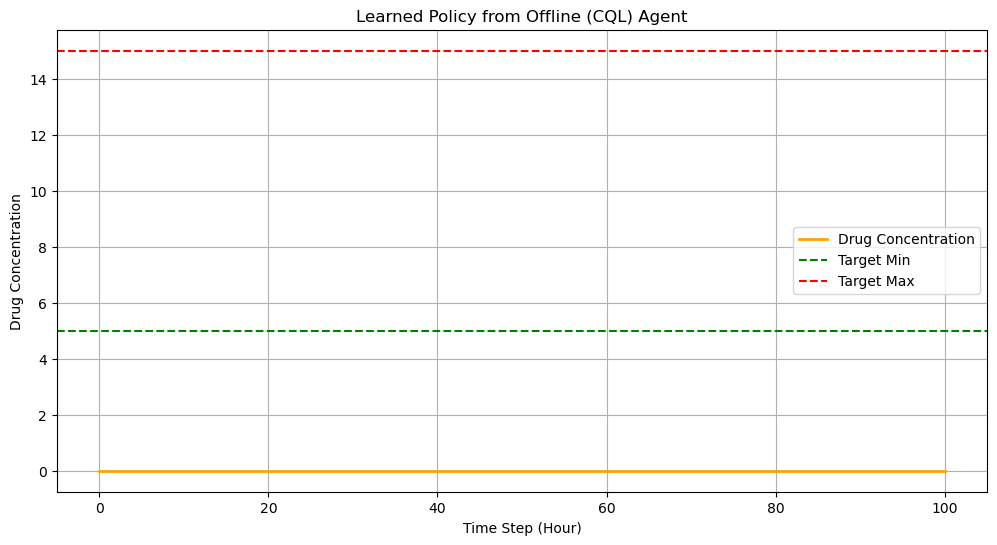

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Initialization ---
# Ensure you have your stochastic environment created in the 'env' variable
# and your trained offline agent in the 'cql' variable.
env = PatientEnvGymShapedReward()
obs, info = env.reset() 

concentrations = [obs[0]] # Store the history of concentrations for plotting

# --- 2. Run one full episode with the OFFLINE-trained agent ---
print("--- Running simulation with the offline-trained CQL agent ---")
max_steps = 100 
for _ in range(max_steps):
    
    # a. Get the best action from the CQL agent's brain 🧠
    # d3rlpy's predict method expects a batch, so we add a dimension to our obs
    action= cql.predict(np.expand_dims(obs, axis=0))
    
    # b. Take that action in the environment
    obs, reward, terminated, truncated, info = env.step(action)
    
    # c. Store the result for plotting
    concentrations.append(obs[0])
    
    # d. If the episode ends, stop the loop
    if terminated or truncated:
        break

# --- 3. Plot the results ---
plt.figure(figsize=(12, 6))
plt.plot(concentrations, label='Drug Concentration', color='orange', linewidth=2)
plt.axhline(y=env.target_min, color='green', linestyle='--', label='Target Min')
plt.axhline(y=env.target_max, color='red', linestyle='--', label='Target Max')
plt.title("Learned Policy from Offline (CQL) Agent")
plt.xlabel("Time Step (Hour)")
plt.ylabel("Drug Concentration")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
import numpy as np
from tqdm import tqdm # A library for progress bars

# --- 1. Initialization ---
num_episodes = 100
env = PatientEnvGymShapedReward()

# Lists to store the results from each episode
all_total_rewards = []
all_times_in_window = []
all_toxic_events = []

print(f"--- Starting evaluation of CQL agent for {num_episodes} episodes ---")

# --- 2. Evaluation Loop ---
for _ in tqdm(range(num_episodes)):
    obs, info = env.reset()
    
    # Metrics for this single episode
    episode_reward = 0
    steps_in_window = 0
    toxic_events = 0
    
    # Run one full episode
    for step in range(env.max_steps):
        # Predict and execute action
        action_array = cql.predict(np.expand_dims(obs, axis=0))
        obs, reward, terminated, truncated, info = env.step(action_array)
        
        # Update metrics
        episode_reward += reward
        if env.target_min <= env.current_concentration <= env.target_max:
            steps_in_window += 1
        if env.current_concentration > env.target_max:
            toxic_events += 1
        
        if terminated or truncated:
            break
            
    # After the episode, calculate and store the final metrics
    percent_in_window = (steps_in_window / env.max_steps) * 100
    all_total_rewards.append(episode_reward)
    all_times_in_window.append(percent_in_window)
    all_toxic_events.append(toxic_events)

# --- 3. Calculate and Print Final Statistics ---
mean_reward = np.mean(all_total_rewards)
std_reward = np.std(all_total_rewards)

mean_time_in_window = np.mean(all_times_in_window)
std_time_in_window = np.std(all_times_in_window)

mean_toxic_events = np.mean(all_toxic_events)
std_toxic_events = np.std(all_toxic_events)

print("\n--- CQL Agent Evaluation Results ---")
print(f"Average Total Reward:     {mean_reward:.2f} ± {std_reward:.2f}")
print(f"Time in Therapeutic Window: {mean_time_in_window:.2f}% ± {std_time_in_window:.2f}%")
print(f"Average Toxic Events:     {mean_toxic_events:.2f} ± {std_toxic_events:.2f}")


Shaped Reward Stochastic Environment created!
--- Starting evaluation of CQL agent for 100 episodes ---


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 62.42it/s]



--- CQL Agent Evaluation Results ---
Average Total Reward:     -271.83 ± 0.00
Time in Therapeutic Window: 0.00% ± 0.00%
Average Toxic Events:     0.00 ± 0.00
